In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap
from scipy.stats import pearsonr
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GridSearchCV

## Correlation Heatmaps

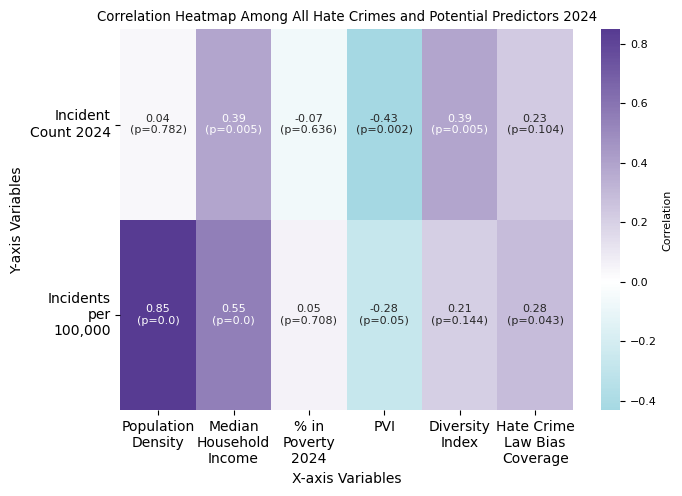

In [2]:
all_crimes = pd.read_excel("C:\\Users\\marin\\Downloads\\DATA 400\\Final Project\\Correlation Data 2024.xlsx", sheet_name="All Crimes")

x_vars = ['Population Density','Median Household Income','% in Poverty 2024','PVI','Diversity Index','Hate Crime Law Bias Coverage']  # X-axis variables
y_vars = ['Incident Count 2024','Incidents per 100,000']  # Y-axis variables

# Function to compute correlation + p-value matrices for custom axes
def corr_p_custom(df, rows, cols):
    corr = pd.DataFrame(index=rows, columns=cols, dtype=float)
    pvals = pd.DataFrame(index=rows, columns=cols, dtype=float)

    for r in rows:
        for c in cols:
            r_val, p_val = pearsonr(df[r], df[c])
            corr.loc[r, c] = r_val
            pvals.loc[r, c] = p_val

    return corr, pvals

corr, pvals = corr_p_custom(all_crimes, y_vars, x_vars)

# Create annotation matrix: "r\n(p)"
annot = corr.round(2).astype(str) + "\n(p=" + pvals.round(3).astype(str) + ")"

# Create custom heatmap scale colors
my_cmap = LinearSegmentedColormap.from_list("custom", ["#50B4C8", "white", "#573B92"])

fig, ax = plt.subplots(figsize=(7, 5))
plt.rcParams.update({'font.size': 8})
sns.heatmap(
    corr,
    ax=ax,
    annot=annot,
    fmt="",
    cmap=my_cmap,
    center=0,
    cbar_kws={"label": "Correlation"}
)

xlabels = [item.get_text() for item in ax.get_xticklabels()]
wrapped_xlabels = [textwrap.fill(label, width=10) for label in xlabels]
ax.set_xticklabels(wrapped_xlabels)
ylabels = [item.get_text() for item in ax.get_yticklabels()]
wrapped_ylabels = [textwrap.fill(label, width=10) for label in ylabels]
ax.set_yticklabels(wrapped_ylabels)

plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.title("Correlation Heatmap Among All Hate Crimes and Potential Predictors 2024")
plt.xlabel("X-axis Variables")
plt.ylabel("Y-axis Variables")
plt.tight_layout()
plt.savefig('AllCrimesCorrelations.png')
plt.show()

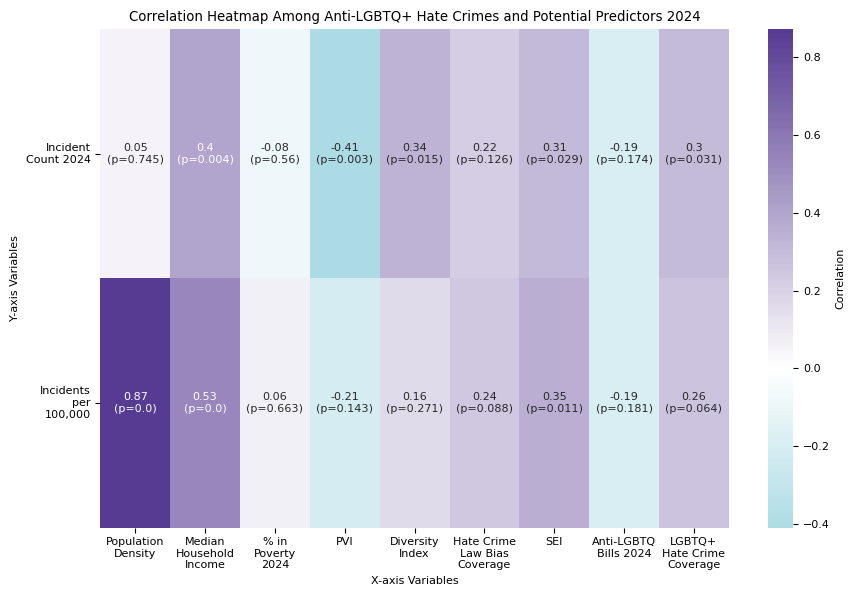

In [3]:
lgbtq_crimes = pd.read_excel("C:\\Users\\marin\\Downloads\\DATA 400\\Final Project\\Correlation Data 2024.xlsx", sheet_name="Anti-LGBTQ+")
lgbtq_crimes.rename(columns={"Anti-LGBTQ Legislation 2024":"Anti-LGBTQ Bills 2024"}, inplace=True)

x_vars = ['Population Density','Median Household Income','% in Poverty 2024','PVI','Diversity Index','Hate Crime Law Bias Coverage',
         'SEI','Anti-LGBTQ Bills 2024','LGBTQ+ Hate Crime Coverage']  # X-axis variables
y_vars = ['Incident Count 2024','Incidents per 100,000']  # Y-axis variables

# Function to compute correlation + p-value matrices for custom axes
def corr_p_custom(df, rows, cols):
    corr = pd.DataFrame(index=rows, columns=cols, dtype=float)
    pvals = pd.DataFrame(index=rows, columns=cols, dtype=float)

    for r in rows:
        for c in cols:
            r_val, p_val = pearsonr(df[r], df[c])
            corr.loc[r, c] = r_val
            pvals.loc[r, c] = p_val

    return corr, pvals

corr, pvals = corr_p_custom(lgbtq_crimes, y_vars, x_vars)

# Create annotation matrix: "r\n(p)"
annot = corr.round(2).astype(str) + "\n(p=" + pvals.round(3).astype(str) + ")"

# Create custom heatmap scale colors
my_cmap = LinearSegmentedColormap.from_list("custom", ["#50B4C8", "white", "#573B92"])

fig, ax = plt.subplots(figsize=(9, 6))
plt.rcParams.update({'font.size': 8})
sns.heatmap(
    corr,
    ax=ax,
    annot=annot,
    fmt="",
    cmap=my_cmap,
    center=0,
    cbar_kws={"label": "Correlation"}
)

xlabels = [item.get_text() for item in ax.get_xticklabels()]
wrapped_xlabels = [textwrap.fill(label, width=10) for label in xlabels]
ax.set_xticklabels(wrapped_xlabels)
ylabels = [item.get_text() for item in ax.get_yticklabels()]
wrapped_ylabels = [textwrap.fill(label, width=10) for label in ylabels]
ax.set_yticklabels(wrapped_ylabels)

plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.title("Correlation Heatmap Among Anti-LGBTQ+ Hate Crimes and Potential Predictors 2024")
plt.xlabel("X-axis Variables")
plt.ylabel("Y-axis Variables")
plt.tight_layout()
plt.savefig('AntiLGBTQCorrelations.png')
plt.show()

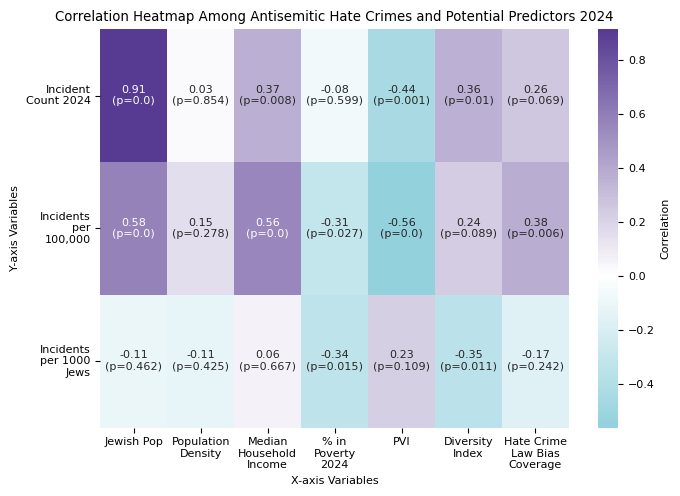

In [38]:
antisemitic_crimes = pd.read_excel("C:\\Users\\marin\\Downloads\\DATA 400\\Final Project\\Correlation Data 2024.xlsx", sheet_name="Antisemitic")

x_vars = ['Jewish Pop','Population Density','Median Household Income','% in Poverty 2024','PVI','Diversity Index',
          'Hate Crime Law Bias Coverage']  # X-axis variables
y_vars = ['Incident Count 2024','Incidents per 100,000','Incidents per 1000 Jews']  # Y-axis variables

# Function to compute correlation + p-value matrices for custom axes
def corr_p_custom(df, rows, cols):
    corr = pd.DataFrame(index=rows, columns=cols, dtype=float)
    pvals = pd.DataFrame(index=rows, columns=cols, dtype=float)

    for r in rows:
        for c in cols:
            r_val, p_val = pearsonr(df[r], df[c])
            corr.loc[r, c] = r_val
            pvals.loc[r, c] = p_val

    return corr, pvals

corr, pvals = corr_p_custom(antisemitic_crimes, y_vars, x_vars)

# Create annotation matrix: "r\n(p)"
annot = corr.round(2).astype(str) + "\n(p=" + pvals.round(3).astype(str) + ")"

# Create custom heatmap scale colors
my_cmap = LinearSegmentedColormap.from_list("custom", ["#50B4C8", "white", "#573B92"])

fig, ax = plt.subplots(figsize=(7, 5))
plt.rcParams.update({'font.size': 8})
sns.heatmap(
    corr,
    ax=ax,
    annot=annot,
    fmt="",
    cmap=my_cmap,
    center=0,
    cbar_kws={"label": "Correlation"}
)

xlabels = [item.get_text() for item in ax.get_xticklabels()]
wrapped_xlabels = [textwrap.fill(label, width=10) for label in xlabels]
ax.set_xticklabels(wrapped_xlabels)
ylabels = [item.get_text() for item in ax.get_yticklabels()]
wrapped_ylabels = [textwrap.fill(label, width=10) for label in ylabels]
ax.set_yticklabels(wrapped_ylabels)

plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.title("Correlation Heatmap Among Antisemitic Hate Crimes and Potential Predictors 2024")
plt.xlabel("X-axis Variables")
plt.ylabel("Y-axis Variables")
plt.tight_layout()
plt.savefig('AntisemiticCorrelations.png')
plt.show()

## Regression Models
### All Hate Crimes

In [5]:
# Rename the columns
all_crimes.rename(columns={"Incidents per 100,000":"Incidents_per_100000", "% in Poverty 2024": "Percent_in_Poverty_2024",
                           "Incident Count 2024":"Incident_Count_2024", "Population Density":"Population_Density",
                           "Median Household Income":"Median_Household_Income", "Diversity Index":"Diversity_Index",
                           "Hate Crime Law Bias Coverage":"Hate_Crime_Law_Bias_Coverage"}, inplace=True)

#### Number of Crimes

In [6]:
# Regression model for number of hate crimes vs. potential predictors
all_crimes_num_model = smf.ols('Incident_Count_2024 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + Hate_Crime_Law_Bias_Coverage', data=all_crimes)
all_crimes_num_fitted = all_crimes_num_model.fit()
print(all_crimes_num_fitted.summary())

                             OLS Regression Results                            
Dep. Variable:     Incident_Count_2024   R-squared:                       0.368
Model:                             OLS   Adj. R-squared:                  0.282
Method:                  Least Squares   F-statistic:                     4.275
Date:                 Mon, 11 May 2026   Prob (F-statistic):            0.00178
Time:                         13:14:36   Log-Likelihood:                -357.31
No. Observations:                   51   AIC:                             728.6
Df Residuals:                       44   BIC:                             742.2
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

#### Crimes per 100,000 Residents

In [7]:
# Regression model for number of hate crimes per 100,000 residents vs. potential predictors
all_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + Hate_Crime_Law_Bias_Coverage', data=all_crimes)
all_crimes_num_fitted = all_crimes_num_model.fit()
print(all_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.789
Model:                              OLS   Adj. R-squared:                  0.760
Method:                   Least Squares   F-statistic:                     27.36
Date:                  Mon, 11 May 2026   Prob (F-statistic):           2.49e-13
Time:                          13:14:37   Log-Likelihood:                -97.101
No. Observations:                    51   AIC:                             208.2
Df Residuals:                        44   BIC:                             221.7
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [8]:
# Regression model for number of hate crimes per 100,000 residents vs. potential predictors
all_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + Diversity_Index + Hate_Crime_Law_Bias_Coverage', data=all_crimes)
all_crimes_num_fitted = all_crimes_num_model.fit()
print(all_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.789
Model:                              OLS   Adj. R-squared:                  0.765
Method:                   Least Squares   F-statistic:                     33.56
Date:                  Mon, 11 May 2026   Prob (F-statistic):           4.07e-14
Time:                          13:14:37   Log-Likelihood:                -97.107
No. Observations:                    51   AIC:                             206.2
Df Residuals:                        45   BIC:                             217.8
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [9]:
# Regression model for number of hate crimes per 100,000 residents vs. potential predictors
all_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + Diversity_Index', data=all_crimes)
all_crimes_num_fitted = all_crimes_num_model.fit()
print(all_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.788
Model:                              OLS   Adj. R-squared:                  0.770
Method:                   Least Squares   F-statistic:                     42.87
Date:                  Mon, 11 May 2026   Prob (F-statistic):           5.82e-15
Time:                          13:14:37   Log-Likelihood:                -97.116
No. Observations:                    51   AIC:                             204.2
Df Residuals:                        46   BIC:                             213.9
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [10]:
# Regression model for number of hate crimes per 100,000 residents vs. potential predictors
all_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Diversity_Index', data=all_crimes)
all_crimes_num_fitted = all_crimes_num_model.fit()
print(all_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.779
Model:                              OLS   Adj. R-squared:                  0.765
Method:                   Least Squares   F-statistic:                     55.31
Date:                  Mon, 11 May 2026   Prob (F-statistic):           1.88e-15
Time:                          13:14:37   Log-Likelihood:                -98.201
No. Observations:                    51   AIC:                             204.4
Df Residuals:                        47   BIC:                             212.1
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [11]:
# Regression model for number of hate crimes per 100,000 residents vs. potential predictors
all_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income', data=all_crimes)
all_crimes_num_fitted = all_crimes_num_model.fit()
print(all_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.776
Model:                              OLS   Adj. R-squared:                  0.767
Method:                   Least Squares   F-statistic:                     83.29
Date:                  Mon, 11 May 2026   Prob (F-statistic):           2.47e-16
Time:                          13:14:37   Log-Likelihood:                -98.543
No. Observations:                    51   AIC:                             203.1
Df Residuals:                        48   BIC:                             208.9
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

### LGBTQ+ Hate Crimes

In [12]:
# Rename the columns
lgbtq_crimes.rename(columns={"Incidents per 100,000":"Incidents_per_100000", "% in Poverty 2024": "Percent_in_Poverty_2024",
                             "Incident Count 2024":"Incident_Count_2024", "Population Density":"Population_Density",
                             "Median Household Income":"Median_Household_Income", "Diversity Index":"Diversity_Index",
                             "Hate Crime Law Bias Coverage":"Hate_Crime_Law_Bias_Coverage", 
                             "Anti-LGBTQ Bills 2024":"AntiLGBTQ_Legislation_2024", 
                             "LGBTQ+ Hate Crime Coverage":"LGBTQ_Hate_Crime_Coverage"}, inplace=True)

#### Number of Crimes

In [13]:
# Regression model for number of hate crimes vs. potential predictors
lgbtq_crimes_num_model = smf.ols('Incident_Count_2024 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + Hate_Crime_Law_Bias_Coverage + SEI + AntiLGBTQ_Legislation_2024 + LGBTQ_Hate_Crime_Coverage', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                            
Dep. Variable:     Incident_Count_2024   R-squared:                       0.383
Model:                             OLS   Adj. R-squared:                  0.248
Method:                  Least Squares   F-statistic:                     2.830
Date:                 Mon, 11 May 2026   Prob (F-statistic):             0.0110
Time:                         13:14:37   Log-Likelihood:                -285.60
No. Observations:                   51   AIC:                             591.2
Df Residuals:                       41   BIC:                             610.5
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Interc

#### Crimes per 100,000 Residents

In [14]:
# Regression model for number of hate crimes per 100,000 residents vs. potential predictors
lgbtq_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + Hate_Crime_Law_Bias_Coverage + SEI + AntiLGBTQ_Legislation_2024 + LGBTQ_Hate_Crime_Coverage', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.838
Model:                              OLS   Adj. R-squared:                  0.803
Method:                   Least Squares   F-statistic:                     23.62
Date:                  Mon, 11 May 2026   Prob (F-statistic):           1.61e-13
Time:                          13:14:37   Log-Likelihood:                -30.143
No. Observations:                    51   AIC:                             80.29
Df Residuals:                        41   BIC:                             99.61
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [15]:
lgbtq_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + Hate_Crime_Law_Bias_Coverage + SEI + LGBTQ_Hate_Crime_Coverage', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.838
Model:                              OLS   Adj. R-squared:                  0.807
Method:                   Least Squares   F-statistic:                     27.21
Date:                  Mon, 11 May 2026   Prob (F-statistic):           2.98e-14
Time:                          13:14:37   Log-Likelihood:                -30.150
No. Observations:                    51   AIC:                             78.30
Df Residuals:                        42   BIC:                             95.69
Df Model:                             8                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [16]:
lgbtq_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + Hate_Crime_Law_Bias_Coverage + SEI', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.838
Model:                              OLS   Adj. R-squared:                  0.812
Method:                   Least Squares   F-statistic:                     31.83
Date:                  Mon, 11 May 2026   Prob (F-statistic):           5.04e-15
Time:                          13:14:37   Log-Likelihood:                -30.150
No. Observations:                    51   AIC:                             76.30
Df Residuals:                        43   BIC:                             91.75
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [17]:
lgbtq_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index + SEI', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.838
Model:                              OLS   Adj. R-squared:                  0.815
Method:                   Least Squares   F-statistic:                     37.83
Date:                  Mon, 11 May 2026   Prob (F-statistic):           8.41e-16
Time:                          13:14:37   Log-Likelihood:                -30.246
No. Observations:                    51   AIC:                             74.49
Df Residuals:                        44   BIC:                             88.01
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [18]:
lgbtq_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + PVI + Diversity_Index', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.831
Model:                              OLS   Adj. R-squared:                  0.812
Method:                   Least Squares   F-statistic:                     44.27
Date:                  Mon, 11 May 2026   Prob (F-statistic):           2.82e-16
Time:                          13:14:37   Log-Likelihood:                -31.263
No. Observations:                    51   AIC:                             74.53
Df Residuals:                        45   BIC:                             86.12
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [19]:
lgbtq_crimes_num_model = smf.ols('Incidents_per_100000 ~ Population_Density + Median_Household_Income + Percent_in_Poverty_2024 + Diversity_Index', data=lgbtq_crimes)
lgbtq_crimes_num_fitted = lgbtq_crimes_num_model.fit()
print(lgbtq_crimes_num_fitted.summary())

                             OLS Regression Results                             
Dep. Variable:     Incidents_per_100000   R-squared:                       0.827
Model:                              OLS   Adj. R-squared:                  0.812
Method:                   Least Squares   F-statistic:                     55.08
Date:                  Mon, 11 May 2026   Prob (F-statistic):           5.76e-17
Time:                          13:14:37   Log-Likelihood:                -31.822
No. Observations:                    51   AIC:                             73.64
Df Residuals:                        46   BIC:                             83.30
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

## Lasso Regression
### All Hate Crimes

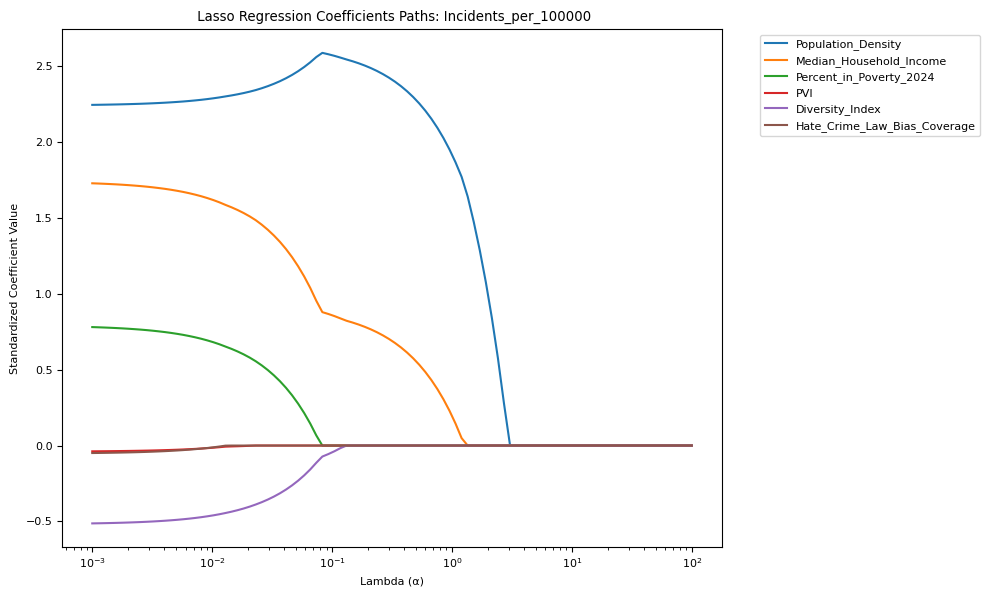

In [20]:
X = all_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index','Hate_Crime_Law_Bias_Coverage']]
y = all_crimes["Incidents_per_100000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title(" Lasso Regression Coefficients Paths: Incidents_per_100000")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 0.0183


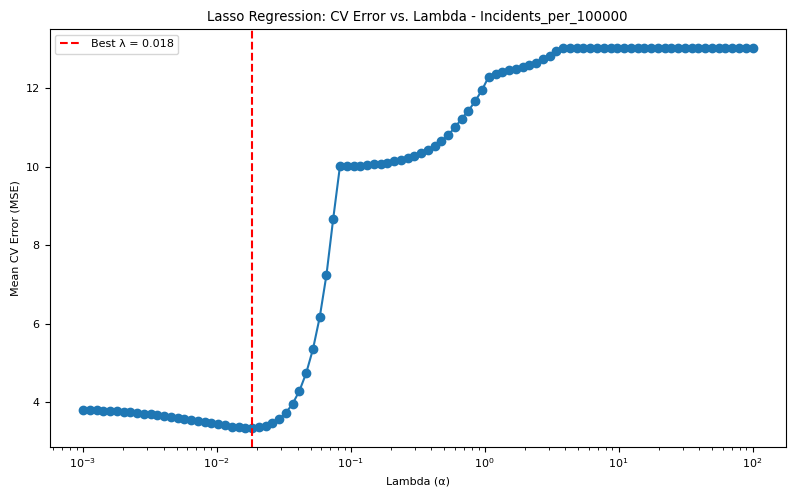

                       Variable  Coefficient
0            Population_Density     2.324150
1       Median_Household_Income     1.533273
2       Percent_in_Poverty_2024     0.601350
4               Diversity_Index    -0.415090
3                           PVI    -0.003233
5  Hate_Crime_Law_Bias_Coverage    -0.000000
R2 =  0.7879016978416379


In [21]:
alphas = np.logspace(-3, 2, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

gs_lasso.fit(X_scaled, y)

best_alpha = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda - Incidents_per_100000")
plt.legend()
plt.tight_layout()
plt.show()

lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coefs_df = lasso_coefs.reset_index()
lasso_coefs_df.columns = ["Variable", "Coefficient"]
lasso_coefs_df = lasso_coefs_df.reindex(lasso_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(lasso_coefs_df)
print("R2 = ", lasso_best.score(X_scaled, y))

### Anti-LGBTQ+ Hate Crimes

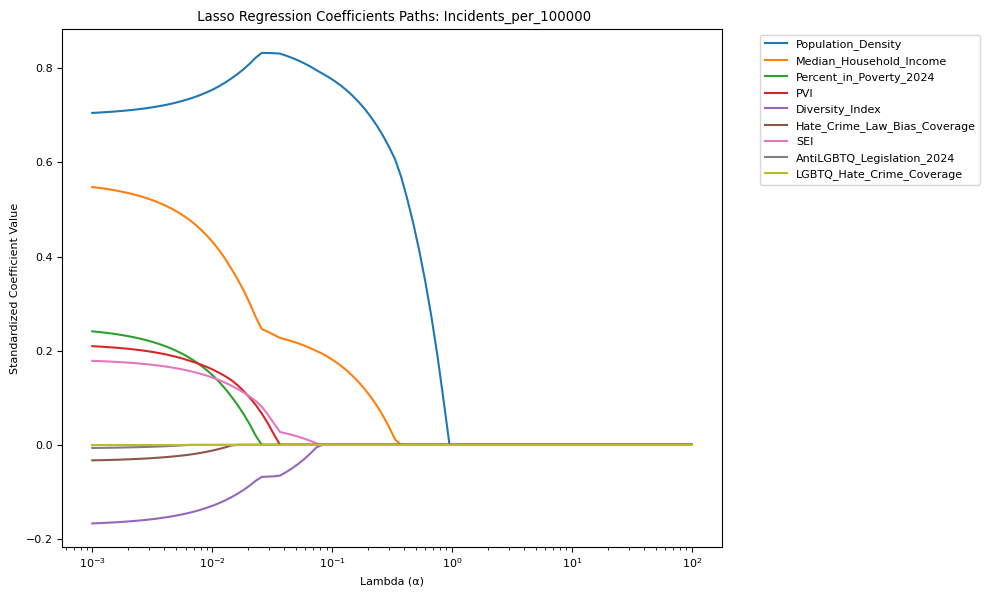

In [22]:
X = lgbtq_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index','Hate_Crime_Law_Bias_Coverage',
                'SEI','AntiLGBTQ_Legislation_2024','LGBTQ_Hate_Crime_Coverage']]
y = lgbtq_crimes["Incidents_per_100000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title(" Lasso Regression Coefficients Paths: Incidents_per_100000")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 0.0040


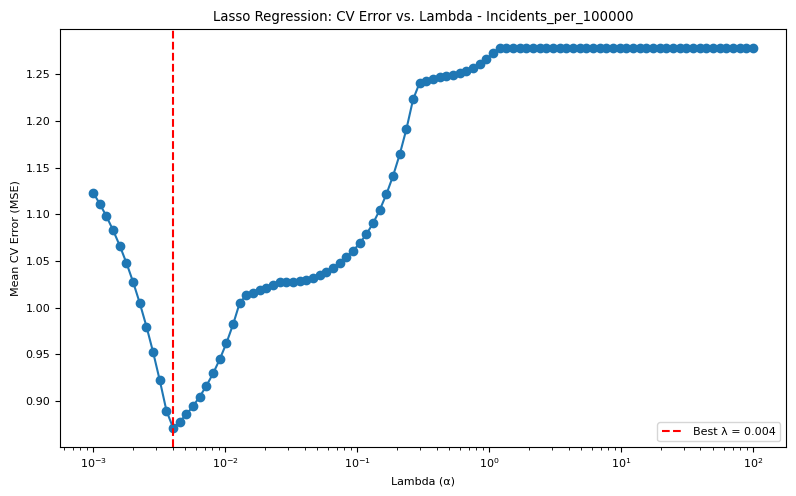

                       Variable  Coefficient
0            Population_Density     0.721879
1       Median_Household_Income     0.508841
2       Percent_in_Poverty_2024     0.209871
3                           PVI     0.192499
6                           SEI     0.166571
4               Diversity_Index    -0.154339
5  Hate_Crime_Law_Bias_Coverage    -0.026263
7    AntiLGBTQ_Legislation_2024    -0.003013
8     LGBTQ_Hate_Crime_Coverage    -0.000000
R2 =  0.8378086962519115


In [23]:
alphas = np.logspace(-3, 2, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

gs_lasso.fit(X_scaled, y)

best_alpha = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda - Incidents_per_100000")
plt.legend()
plt.tight_layout()
plt.show()

lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coefs_df = lasso_coefs.reset_index()
lasso_coefs_df.columns = ["Variable", "Coefficient"]
lasso_coefs_df = lasso_coefs_df.reindex(lasso_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(lasso_coefs_df)
print("R2 = ", lasso_best.score(X_scaled, y))

### Antisemitic Hate Crimes

In [39]:
# Rename the columns
antisemitic_crimes.rename(columns={"Incidents per 100,000":"Incidents_per_100000", "% in Poverty 2024": "Percent_in_Poverty_2024",
                                   "Incident Count 2024":"Incident_Count_2024", "Population Density":"Population_Density",
                                   "Median Household Income":"Median_Household_Income", "Diversity Index":"Diversity_Index",
                                   "Hate Crime Law Bias Coverage":"Hate_Crime_Law_Bias_Coverage", 
                                   "Incidents per 1000 Jews":"Incidents_per_1000_Jews", "Jewish Pop":"Jewish_Population"}, inplace=True)

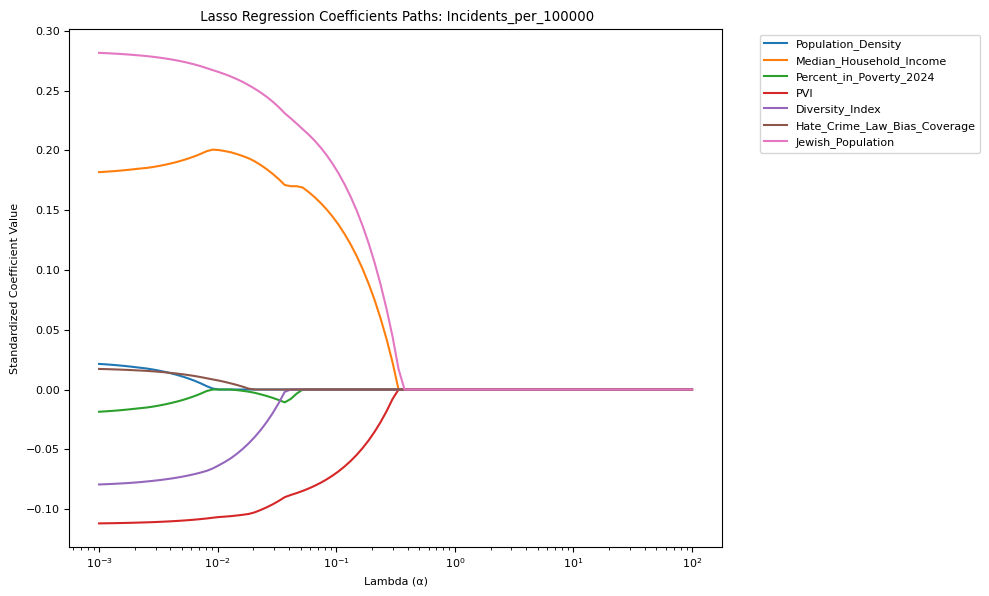

In [40]:
X = antisemitic_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index',
                        'Hate_Crime_Law_Bias_Coverage',"Jewish_Population"]]
y = antisemitic_crimes["Incidents_per_100000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title(" Lasso Regression Coefficients Paths: Incidents_per_100000")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 0.0739


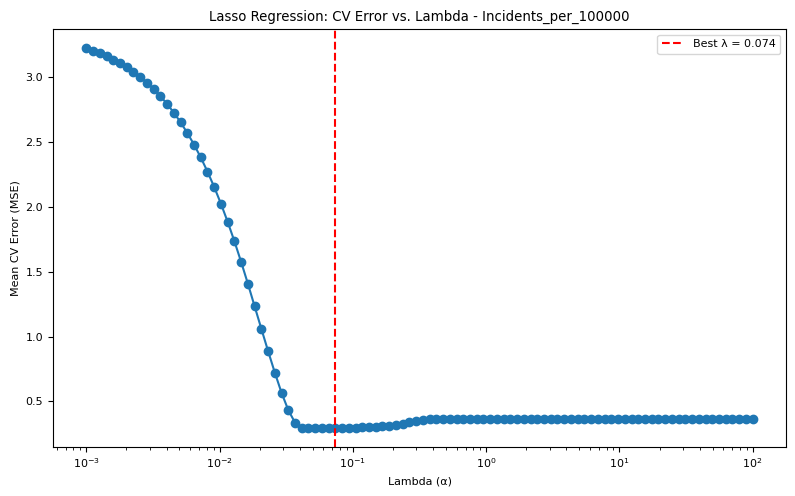

                       Variable  Coefficient
6             Jewish_Population     0.202365
1       Median_Household_Income     0.156005
3                           PVI    -0.077987
2       Percent_in_Poverty_2024    -0.000000
0            Population_Density     0.000000
4               Diversity_Index    -0.000000
5  Hate_Crime_Law_Bias_Coverage     0.000000
R2 =  0.49846413906567877


In [41]:
alphas = np.logspace(-3, 2, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

gs_lasso.fit(X_scaled, y)

best_alpha = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda - Incidents_per_100000")
plt.legend()
plt.tight_layout()
plt.show()

lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coefs_df = lasso_coefs.reset_index()
lasso_coefs_df.columns = ["Variable", "Coefficient"]
lasso_coefs_df = lasso_coefs_df.reindex(lasso_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(lasso_coefs_df)
print("R2 = ", lasso_best.score(X_scaled, y))

#### Model for Crimes per 1000 Jews

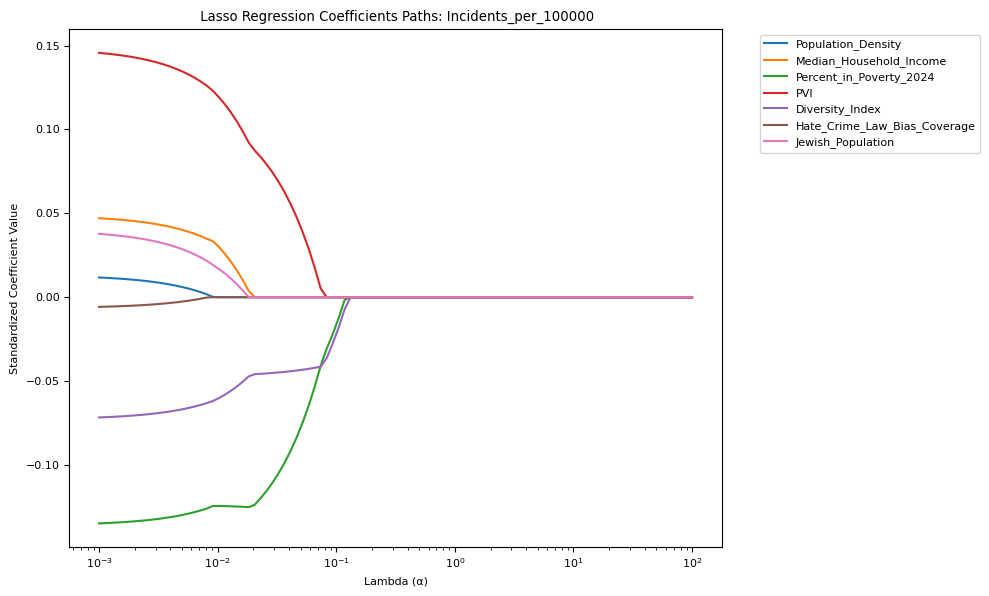

In [42]:
X = antisemitic_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index',
                        'Hate_Crime_Law_Bias_Coverage',"Jewish_Population"]]
y = antisemitic_crimes["Incidents_per_1000_Jews"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title(" Lasso Regression Coefficients Paths: Incidents_per_100000")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 0.0129


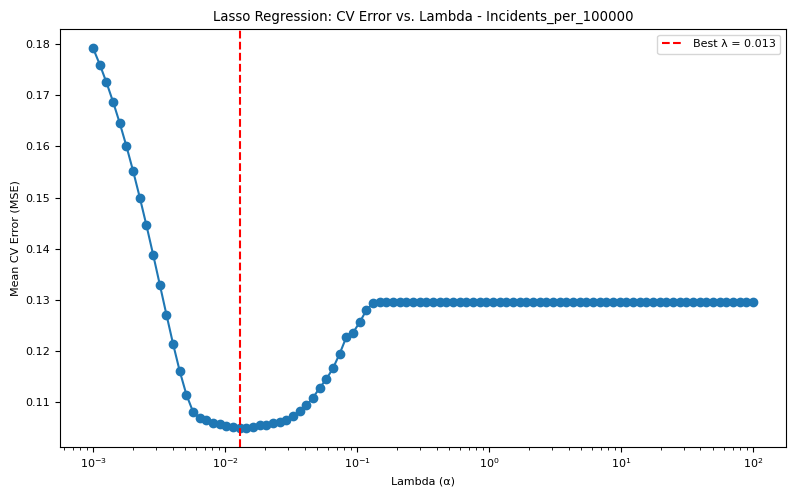

                       Variable  Coefficient
2       Percent_in_Poverty_2024    -0.124620
3                           PVI     0.110202
4               Diversity_Index    -0.055805
1       Median_Household_Income     0.021242
6             Jewish_Population     0.011166
0            Population_Density     0.000000
5  Hate_Crime_Law_Bias_Coverage    -0.000000
R2 =  0.2783611231181574


In [43]:
alphas = np.logspace(-3, 2, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

gs_lasso.fit(X_scaled, y)

best_alpha = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda - Incidents_per_100000")
plt.legend()
plt.tight_layout()
plt.show()

lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coefs_df = lasso_coefs.reset_index()
lasso_coefs_df.columns = ["Variable", "Coefficient"]
lasso_coefs_df = lasso_coefs_df.reindex(lasso_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(lasso_coefs_df)
print("R2 = ", lasso_best.score(X_scaled, y))

### ADL Incidents

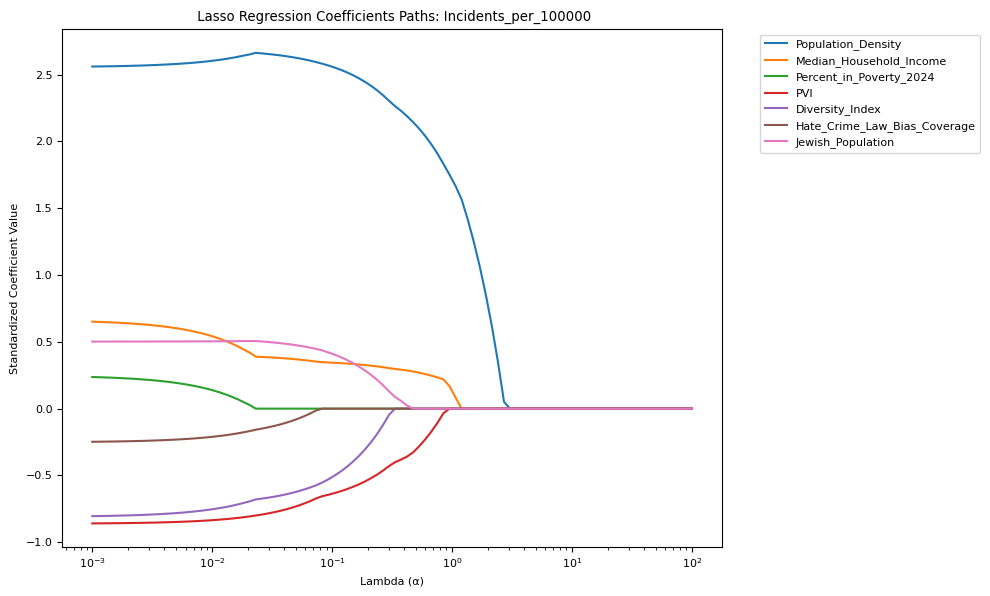

In [44]:
X = antisemitic_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index',
                        'Hate_Crime_Law_Bias_Coverage',"Jewish_Population"]]
y = antisemitic_crimes["ADL Incidents per 100,000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 2, 100)
coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title(" Lasso Regression Coefficients Paths: Incidents_per_100000")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 0.0010


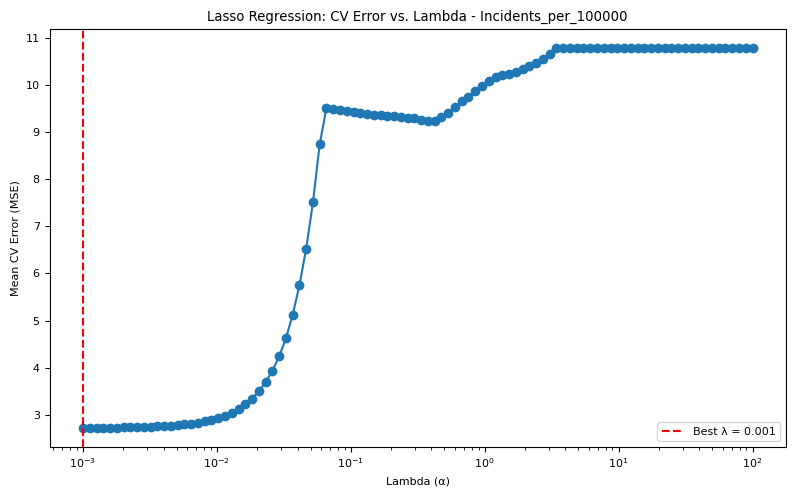

                       Variable  Coefficient
0            Population_Density     2.559802
3                           PVI    -0.858664
4               Diversity_Index    -0.804532
1       Median_Household_Income     0.650725
6             Jewish_Population     0.501847
5  Hate_Crime_Law_Bias_Coverage    -0.248009
2       Percent_in_Poverty_2024     0.236584
R2 =  0.8799623635979894


In [45]:
alphas = np.logspace(-3, 2, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs_lasso = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid={"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=cv,
    return_train_score=True,
)

gs_lasso.fit(X_scaled, y)

best_alpha = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs_lasso.cv_results_["mean_test_score"]  # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: CV Error vs. Lambda - Incidents_per_100000")
plt.legend()
plt.tight_layout()
plt.show()

lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coefs_df = lasso_coefs.reset_index()
lasso_coefs_df.columns = ["Variable", "Coefficient"]
lasso_coefs_df = lasso_coefs_df.reindex(lasso_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(lasso_coefs_df)
print("R2 = ", lasso_best.score(X_scaled, y))

## Ridge Regression
### All Hate Crimes

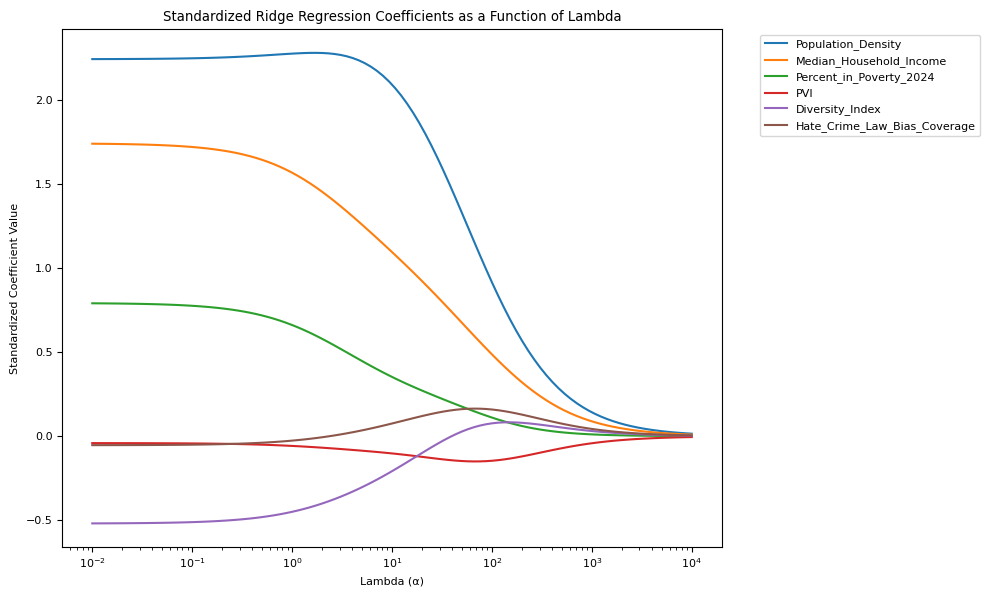

In [29]:
X = all_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index','Hate_Crime_Law_Bias_Coverage']]
y = all_crimes["Incidents_per_100000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 4, 100) # λ from 0.01 to 10,000
coefs = []
for alpha in alphas:
 ridge = Ridge(alpha=alpha)
 ridge.fit(X_scaled, y)
 coefs.append(ridge.coef_)
coefs = np.array(coefs)
# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Ridge Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 0.2848


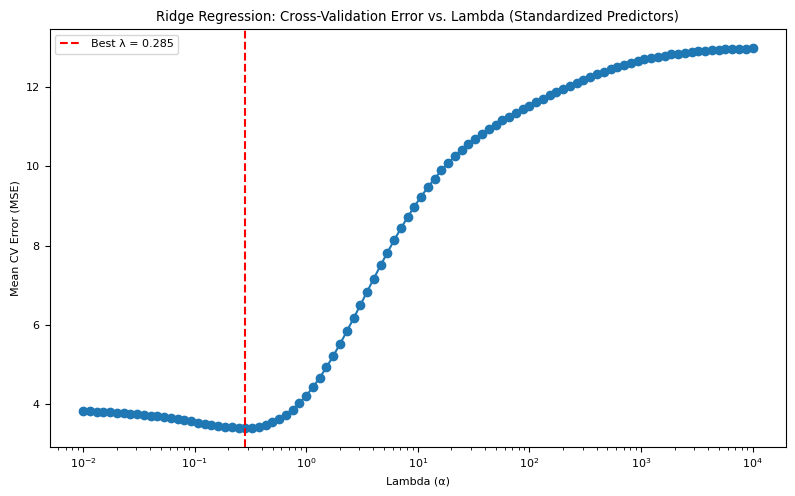

                       Variable  Coefficient
0            Population_Density     2.255453
1       Median_Household_Income     1.682454
2       Percent_in_Poverty_2024     0.747453
4               Diversity_Index    -0.496188
3                           PVI    -0.046447
5  Hate_Crime_Law_Bias_Coverage    -0.044573
R2 =  0.7885551535232134


In [30]:
alphas = np.logspace(-2, 4, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
 estimator=Ridge(),
 param_grid={"alpha": alphas},
 scoring="neg_mean_squared_error",
 cv=cv,
 return_train_score=True,
)

gs.fit(X_scaled, y)

best_alpha = gs.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs.cv_results_["mean_test_score"] # convert from negative MSE

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Ridge Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_best.coef_, index=X.columns)
ridge_coefs_df = ridge_coefs.reset_index()
ridge_coefs_df.columns = ["Variable", "Coefficient"]
ridge_coefs_df = ridge_coefs_df.reindex(ridge_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(ridge_coefs_df)
print("R2 = ", ridge_best.score(X_scaled, y))

### Anti-LGBTQ+ Hate Crimes

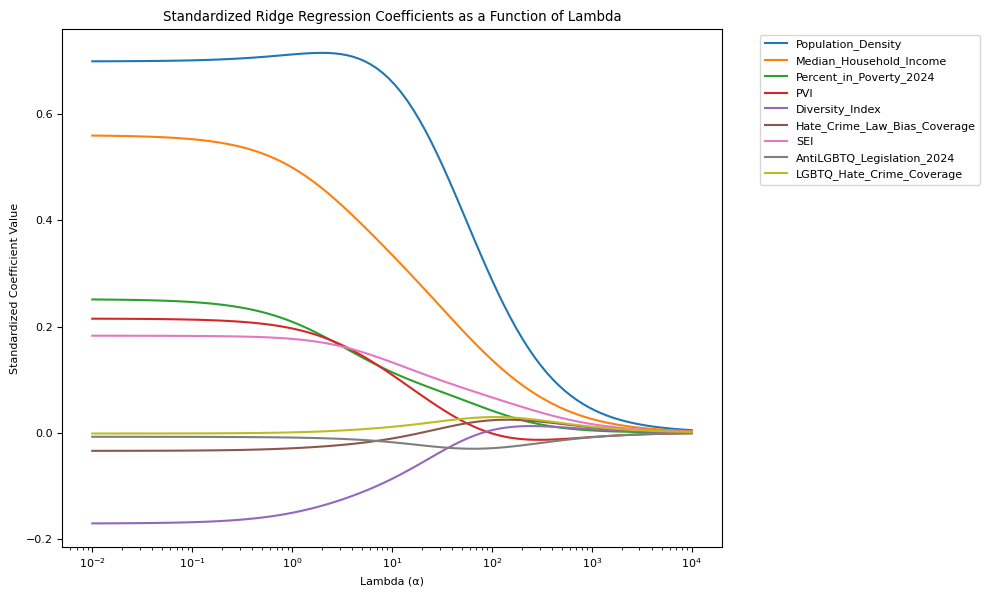

In [31]:
X = lgbtq_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index','Hate_Crime_Law_Bias_Coverage',
                 'SEI','AntiLGBTQ_Legislation_2024','LGBTQ_Hate_Crime_Coverage']]
y = lgbtq_crimes["Incidents_per_100000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 4, 100) # λ from 0.01 to 10,000
coefs = []
for alpha in alphas:
 ridge = Ridge(alpha=alpha)
 ridge.fit(X_scaled, y)
 coefs.append(ridge.coef_)
coefs = np.array(coefs)
# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Ridge Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 1.7475


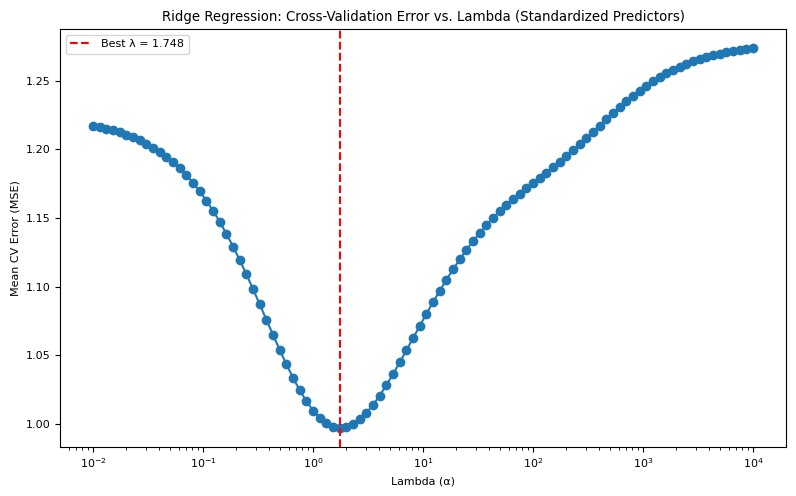

                       Variable  Coefficient
0            Population_Density     0.715597
1       Median_Household_Income     0.468992
2       Percent_in_Poverty_2024     0.188510
3                           PVI     0.184364
6                           SEI     0.171612
4               Diversity_Index    -0.140537
5  Hate_Crime_Law_Bias_Coverage    -0.026803
7    AntiLGBTQ_Legislation_2024    -0.010129
8     LGBTQ_Hate_Crime_Coverage     0.001993
R2 =  0.8366800958324885


In [32]:
alphas = np.logspace(-2, 4, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
 estimator=Ridge(),
 param_grid={"alpha": alphas},
 scoring="neg_mean_squared_error",
 cv=cv,
 return_train_score=True,
)

gs.fit(X_scaled, y)

best_alpha = gs.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs.cv_results_["mean_test_score"] # convert from negative MSE

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Ridge Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_best.coef_, index=X.columns)
ridge_coefs_df = ridge_coefs.reset_index()
ridge_coefs_df.columns = ["Variable", "Coefficient"]
ridge_coefs_df = ridge_coefs_df.reindex(ridge_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(ridge_coefs_df)
print("R2 = ", ridge_best.score(X_scaled, y))

### Antisemitic Hate Crimes
#### Crimes per 100,000 Residents

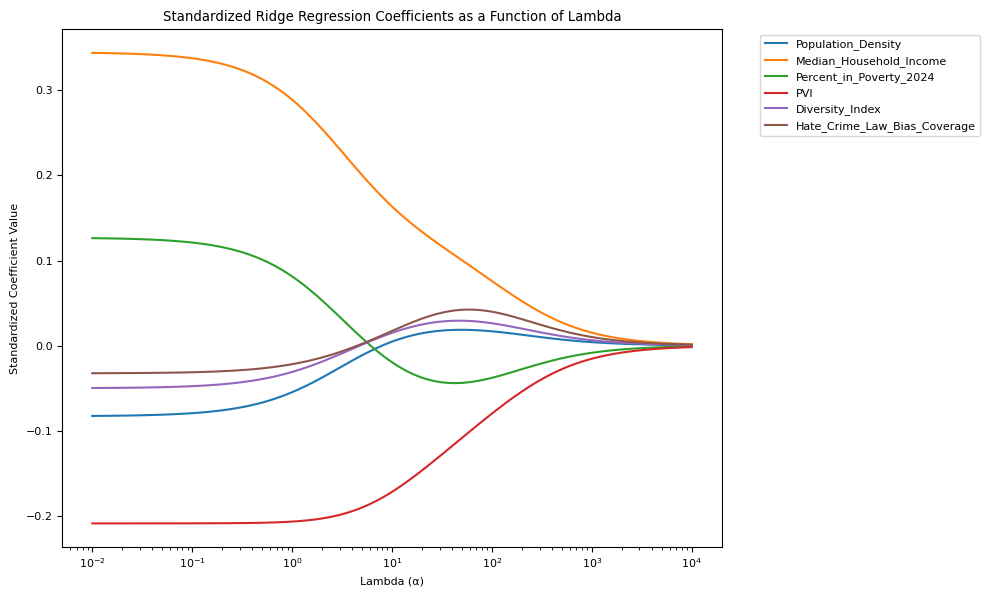

In [33]:
X = antisemitic_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index',
                        'Hate_Crime_Law_Bias_Coverage']]
y = antisemitic_crimes["Incidents_per_100000"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 4, 100) # λ from 0.01 to 10,000
coefs = []
for alpha in alphas:
 ridge = Ridge(alpha=alpha)
 ridge.fit(X_scaled, y)
 coefs.append(ridge.coef_)
coefs = np.array(coefs)
# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Ridge Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 49.7702


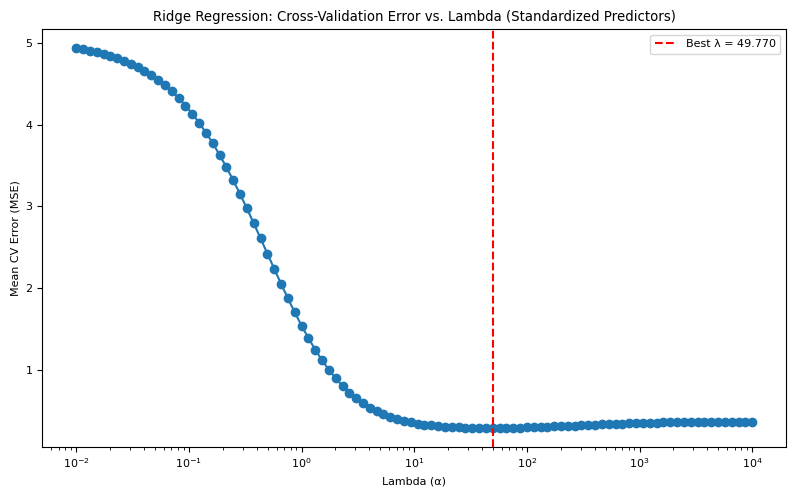

                       Variable  Coefficient
3                           PVI    -0.108704
1       Median_Household_Income     0.100625
2       Percent_in_Poverty_2024    -0.043789
5  Hate_Crime_Law_Bias_Coverage     0.042116
4               Diversity_Index     0.029301
0            Population_Density     0.018625
R2 =  0.3303331646093228


In [34]:
alphas = np.logspace(-2, 4, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
 estimator=Ridge(),
 param_grid={"alpha": alphas},
 scoring="neg_mean_squared_error",
 cv=cv,
 return_train_score=True,
)

gs.fit(X_scaled, y)

best_alpha = gs.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs.cv_results_["mean_test_score"] # convert from negative MSE

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Ridge Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_best.coef_, index=X.columns)
ridge_coefs_df = ridge_coefs.reset_index()
ridge_coefs_df.columns = ["Variable", "Coefficient"]
ridge_coefs_df = ridge_coefs_df.reindex(ridge_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(ridge_coefs_df)
print("R2 = ", ridge_best.score(X_scaled, y))

#### Crimes per 1,000 Jews

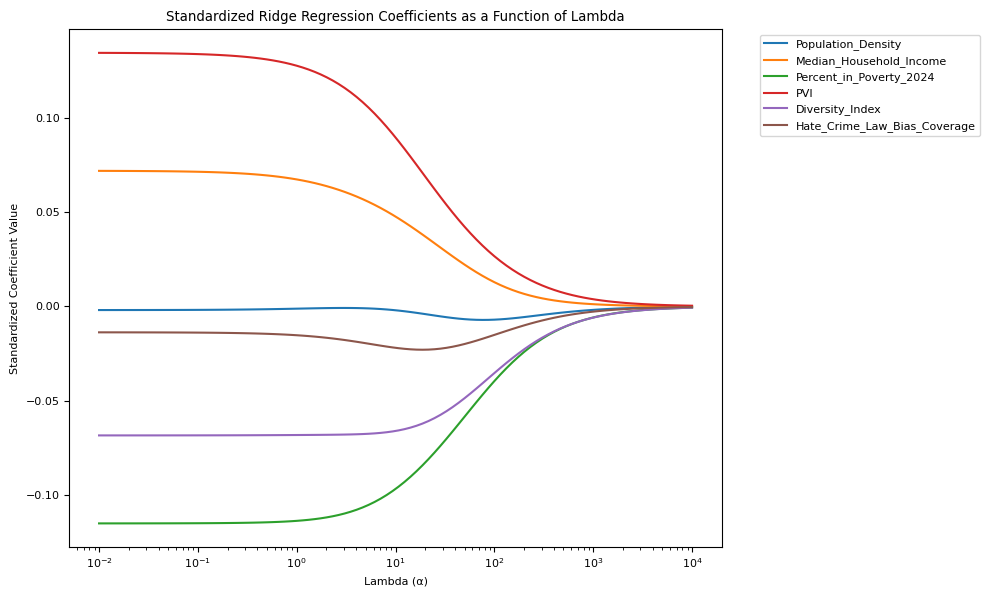

In [35]:
X = antisemitic_crimes[['Population_Density','Median_Household_Income','Percent_in_Poverty_2024','PVI','Diversity_Index',
                        'Hate_Crime_Law_Bias_Coverage']]
y = antisemitic_crimes["Incidents_per_1000_Jews"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-2, 4, 100) # λ from 0.01 to 10,000
coefs = []
for alpha in alphas:
 ridge = Ridge(alpha=alpha)
 ridge.fit(X_scaled, y)
 coefs.append(ridge.coef_)
coefs = np.array(coefs)
# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Ridge Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha): 12.3285


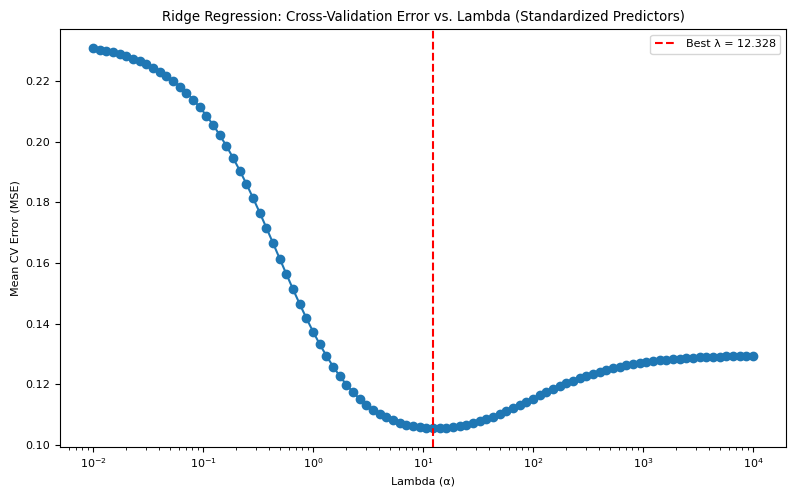

                       Variable  Coefficient
2       Percent_in_Poverty_2024    -0.093163
3                           PVI     0.083695
4               Diversity_Index    -0.065150
1       Median_Household_Income     0.044728
5  Hate_Crime_Law_Bias_Coverage    -0.022489
0            Population_Density    -0.002538
R2 =  0.2692908276702167


In [36]:
alphas = np.logspace(-2, 4, 100)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
 estimator=Ridge(),
 param_grid={"alpha": alphas},
 scoring="neg_mean_squared_error",
 cv=cv,
 return_train_score=True,
)

gs.fit(X_scaled, y)

best_alpha = gs.best_params_["alpha"]
print(f"Best lambda (alpha): {best_alpha:.4f}")

mean_cv_mse = -gs.cv_results_["mean_test_score"] # convert from negative MSE

plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse, marker="o")
plt.axvline(best_alpha, linestyle="--", color="red", label=f"Best λ = {best_alpha:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Ridge Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_scaled, y)
ridge_coefs = pd.Series(ridge_best.coef_, index=X.columns)
ridge_coefs_df = ridge_coefs.reset_index()
ridge_coefs_df.columns = ["Variable", "Coefficient"]
ridge_coefs_df = ridge_coefs_df.reindex(ridge_coefs_df["Coefficient"].abs().sort_values(ascending=False).index)
print(ridge_coefs_df)
print("R2 = ", ridge_best.score(X_scaled, y))